In [4]:
%load_ext autoreload
%autoreload 2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
df = pd.read_csv('../../dataset/raw/heart.csv')
dados = pd.DataFrame(df)

In [6]:
dados.dtypes

Age                 int64
Sex                   str
ChestPainType         str
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG            str
MaxHR               int64
ExerciseAngina        str
Oldpeak           float64
ST_Slope              str
HeartDisease        int64
dtype: object

In [7]:
dados.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [8]:
dados.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [9]:
dados[dados['RestingBP'] == 0].count()

Age               1
Sex               1
ChestPainType     1
RestingBP         1
Cholesterol       1
FastingBS         1
RestingECG        1
MaxHR             1
ExerciseAngina    1
Oldpeak           1
ST_Slope          1
HeartDisease      1
dtype: int64

In [10]:
dados2 = dados.loc[dados['RestingBP'] != 0]

In [11]:
dados2[dados2['Cholesterol'] == 0].count()

Age               171
Sex               171
ChestPainType     171
RestingBP         171
Cholesterol       171
FastingBS         171
RestingECG        171
MaxHR             171
ExerciseAngina    171
Oldpeak           171
ST_Slope          171
HeartDisease      171
dtype: int64

In [12]:
dados2['Cholesterol'] = dados2['Cholesterol'].replace(0, np.nan)

In [13]:
dados2.isnull().sum()

Age                 0
Sex                 0
ChestPainType       0
RestingBP           0
Cholesterol       171
FastingBS           0
RestingECG          0
MaxHR               0
ExerciseAngina      0
Oldpeak             0
ST_Slope            0
HeartDisease        0
dtype: int64

In [14]:
dados2['Cholesterol'] = dados2['Cholesterol'].fillna(dados2.groupby('HeartDisease')['Cholesterol'].transform('mean'))

<Axes: xlabel='Cholesterol', ylabel='Count'>

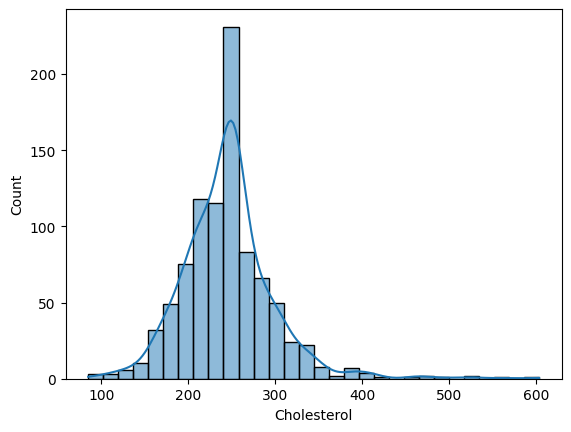

In [15]:
sns.histplot(dados2, x = 'Cholesterol', bins = 30, kde = True)

In [16]:
dados2.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,917.000000,917.000000,917.000000,917.000000,917.000000,917.000000,917.000000
mean,53.509269,132.540894,245.565666,0.233370,136.789531,0.886696,0.552890
std,9.437636,17.999749,53.409819,0.423206,25.467129,1.066960,0.497466
min,28.000000,80.000000,85.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,214.000000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,250.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [18]:
dados2.to_csv('../../dataset/processed/heart_tratado.csv', sep = ',', encoding = 'utf-8', index = False)